# MDI3003 - Advanced Predictive Analytics
## Lab 06: Time-Series Analysis and Forecasting of Reported Crime Incidents by Time and Location using AR and ARIMA Models

**Sarah Blessy N** — **23MID 0296**

**Dataset:** City of Chicago - Crimes 2001 to Present
(API Endpoint: `https://data.cityofchicago.org/resource/ijzp-q8t2.json`)

This version avoids user-defined functions entirely (`def`). Every step — data fetching, cleaning, modeling, and each visualization — is written as plain, inline top-level code in its own cell with its own `plt.show()`. Library functions (pandas, numpy, statsmodels, sklearn) are still used, since those aren't user-defined functions.

## Imports, Configuration, and Setup

In [1]:
import json
import platform
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

CONFIG = {
    "dataset_name": "Chicago Crimes - 2001 to Present (Socrata dataset ijzp-q8t2)",
    "dataset_url": "https://data.cityofchicago.org/Public-Safety/Crimes-2001-to-Present/ijzp-q8t2/about_data",
    "soda_endpoint": "https://data.cityofchicago.org/resource/ijzp-q8t2.json",
    "date_col": "date",
    "location_col": "district",
    "primary_location": "001",
    "second_location": "012",
    "category_col": "primary_type",
    "category_value": None,
    "start_date": "2019-01-01",
    "end_date": "2024-12-31",
    "frequency": "W-MON",
    "test_periods": 12,
    "ar_lags": 4,
    "arima_candidates": [(1, 0, 0), (2, 0, 0), (1, 1, 1), (2, 1, 1)],
    "rolling_horizon": 8,
    "rolling_step": 8,
    "max_rows_per_location": 200000,
}

OUT = Path("lab06_outputs")
OUT.mkdir(exist_ok=True)

print(json.dumps(CONFIG, indent=2))

{
  "dataset_name": "Chicago Crimes - 2001 to Present (Socrata dataset ijzp-q8t2)",
  "dataset_url": "https://data.cityofchicago.org/Public-Safety/Crimes-2001-to-Present/ijzp-q8t2/about_data",
  "soda_endpoint": "https://data.cityofchicago.org/resource/ijzp-q8t2.json",
  "date_col": "date",
  "location_col": "district",
  "primary_location": "001",
  "second_location": "012",
  "category_col": "primary_type",
  "category_value": null,
  "start_date": "2019-01-01",
  "end_date": "2024-12-31",
  "frequency": "W-MON",
  "test_periods": 12,
  "ar_lags": 4,
  "arima_candidates": [
    [
      1,
      0,
      0
    ],
    [
      2,
      0,
      0
    ],
    [
      1,
      1,
      1
    ],
    [
      2,
      1,
      1
    ]
  ],
  "rolling_horizon": 8,
  "rolling_step": 8,
  "max_rows_per_location": 200000
}


## District Discovery (Inline — No Functions)

In [2]:
print("Checking district codes available in the dataset...")

params = {
    "$select": "district,count(*) as records",
    "$where": (
        f"date >= '{CONFIG['start_date']}T00:00:00' "
        f"AND date <= '{CONFIG['end_date']}T23:59:59' "
        "AND district IS NOT NULL"
    ),
    "$group": "district",
    "$order": "district",
    "$limit": 100,
}

response = requests.get(CONFIG["soda_endpoint"], params=params, timeout=60)
response.raise_for_status()
data = response.json()

if not data:
    raise ValueError("The Chicago API returned no district information.")

districts = pd.DataFrame(data)
districts["records"] = pd.to_numeric(districts["records"], errors="coerce")
print(districts.to_string(index=False))

Checking district codes available in the dataset...
district  records
     001    75361
     002    69105
     003    72588
     004    81712
     005    61975
     006    90189
     007    68176
     008    91094
     009    62978
     010    63534
     011    89549
     012    80995
     014    50317
     015    52414
     016    52014
     017    41483
     018    73656
     019    71235
     020    29021
     022    46508
     024    48516
     025    74590
     031       70
      16       16


## District Validation (Inline)

In [3]:
available = set(districts["district"].astype(str).str.strip().str.zfill(3))

primary_raw = str(CONFIG["primary_location"]).strip()
primary = primary_raw.zfill(3) if primary_raw.isdigit() else primary_raw

second_raw = str(CONFIG["second_location"]).strip()
second = second_raw.zfill(3) if second_raw.isdigit() else second_raw

print(f"Requested primary district: {primary}")
print(f"Requested second district: {second}")

if primary not in available:
    raise ValueError(f"District {primary} was not found.")
if second not in available:
    raise ValueError(f"District {second} was not found.")

print("District validation successful.")

Requested primary district: 001
Requested second district: 012
District validation successful.


# Full Pipeline — Primary District (`primary`)

### Fetch Crime Records — Primary District

In [4]:
where_primary = (
    f"district = '{primary}' "
    f"AND date >= '{CONFIG['start_date']}T00:00:00' "
    f"AND date <= '{CONFIG['end_date']}T23:59:59'"
)
select_cols_primary = ",".join([CONFIG["date_col"], CONFIG["location_col"], CONFIG["category_col"], "case_number"])

records_primary = []
limit_primary = 50000
offset_primary = 0

print(f"Fetching data for district {primary}...")

while len(records_primary) < CONFIG["max_rows_per_location"]:
    params = {
        "$select": select_cols_primary,
        "$where": where_primary,
        "$order": f"{CONFIG['date_col']} ASC",
        "$limit": min(limit_primary, CONFIG["max_rows_per_location"] - len(records_primary)),
        "$offset": offset_primary,
    }
    print(f"  Downloading rows {offset_primary:,}...")
    response = requests.get(CONFIG["soda_endpoint"], params=params, timeout=60)
    response.raise_for_status()
    batch = response.json()
    if not batch:
        break
    records_primary.extend(batch)
    offset_primary += len(batch)
    if len(batch) < limit_primary:
        break
    time.sleep(0.2)

if not records_primary:
    raise ValueError(f"No crime records found for district {primary}.")

raw_primary = pd.DataFrame(records_primary)
print(f"  Retrieved {len(raw_primary):,} rows.")

Fetching data for district 001...
  Retrieved 75,361 rows.


### Validate and Clean — Primary District

In [5]:
print("DATASET PREVIEW")
print(raw_primary.head())

print("DATASET SHAPE:", raw_primary.shape)
print("COLUMN NAMES:", raw_primary.columns.tolist())

required_primary = {CONFIG["date_col"], CONFIG["location_col"]}
missing_cols_primary = required_primary - set(raw_primary.columns)
if missing_cols_primary:
    raise ValueError(f"Missing required columns: {missing_cols_primary}")

df_primary = raw_primary.copy()
df_primary[CONFIG["date_col"]] = pd.to_datetime(df_primary[CONFIG["date_col"]], errors="coerce")
before_primary = len(df_primary)
df_primary = df_primary.dropna(subset=[CONFIG["date_col"]]).copy()
print(f"Valid timestamps: {len(df_primary):,}/{before_primary:,}")

if "case_number" in df_primary.columns:
    duplicates_primary = df_primary.duplicated(subset=["case_number"]).sum()
    print(f"Duplicate case numbers: {duplicates_primary:,}")
    if duplicates_primary:
        df_primary = df_primary.drop_duplicates(subset=["case_number"])

df_primary[CONFIG["location_col"]] = df_primary[CONFIG["location_col"]].astype(str).str.strip().str.zfill(3)

print("CLEANED DATASET HEAD")
print(df_primary.head())

DATASET PREVIEW
                      date district         primary_type case_number
0  2019-01-01T00:00:00.000      001              BATTERY    JE142696
1  2019-01-01T00:01:00.000      001                THEFT    JC100416
2  2019-01-01T00:01:00.000      001      CRIMINAL DAMAGE    JC102273
3  2019-01-01T00:01:00.000      001   DECEPTIVE PRACTICE    JC341225
4  2019-01-01T00:15:00.000      001  MOTOR VEHICLE THEFT    JC101009
DATASET SHAPE: (75361, 4)
COLUMN NAMES: ['date', 'district', 'primary_type', 'case_number']
Valid timestamps: 75,361/75,361
Duplicate case numbers: 5
CLEANED DATASET HEAD
                 date district         primary_type case_number
0 2019-01-01 00:00:00      001              BATTERY    JE142696
1 2019-01-01 00:01:00      001                THEFT    JC100416
2 2019-01-01 00:01:00      001      CRIMINAL DAMAGE    JC102273
3 2019-01-01 00:01:00      001   DECEPTIVE PRACTICE    JC341225
4 2019-01-01 00:15:00      001  MOTOR VEHICLE THEFT    JC101009


### Data Quality Plot — Primary District

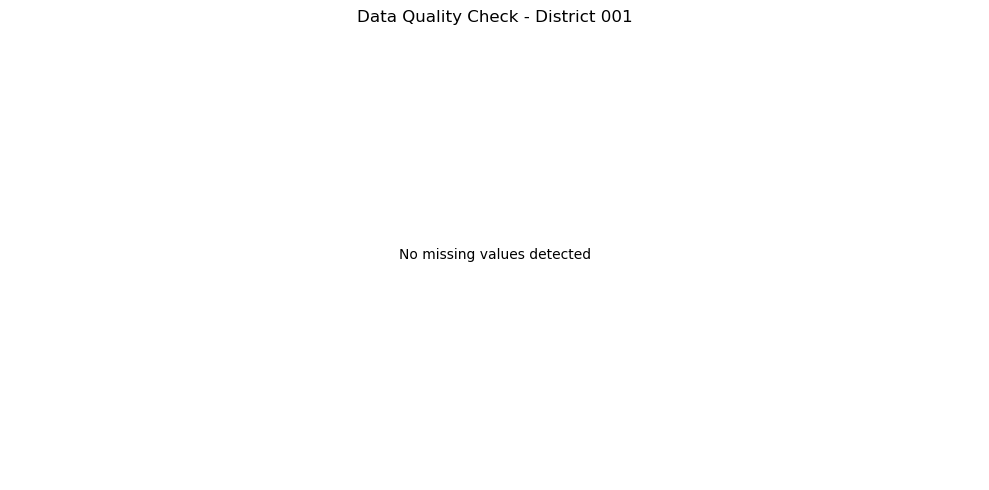

In [6]:
missing_primary = df_primary.isna().sum()
missing_primary = missing_primary[missing_primary > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
if len(missing_primary):
    missing_primary.plot(kind="bar", ax=ax)
    ax.set_ylabel("Missing Values")
    ax.set_title(f"Missing Values - District {primary}")
else:
    ax.text(0.5, 0.5, "No missing values detected", ha="center", va="center")
    ax.set_title(f"Data Quality Check - District {primary}")
    ax.set_axis_off()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

### Build Weekly Time Series — Primary District

In [7]:
loc_primary = df_primary[df_primary[CONFIG["location_col"]] == primary].copy()
if len(loc_primary) == 0:
    raise ValueError(f"No observations for district {primary}")

y_primary = (
    loc_primary.set_index(CONFIG["date_col"])
    .resample(CONFIG["frequency"])
    .size()
    .rename("incidents")
    .asfreq(CONFIG["frequency"], fill_value=0)
)

print(y_primary.describe())

count    314.000000
mean     239.987261
std       77.497933
min       34.000000
25%      193.250000
50%      249.000000
75%      285.500000
max      706.000000
Name: incidents, dtype: float64


### Weekly Trend Plot — Primary District

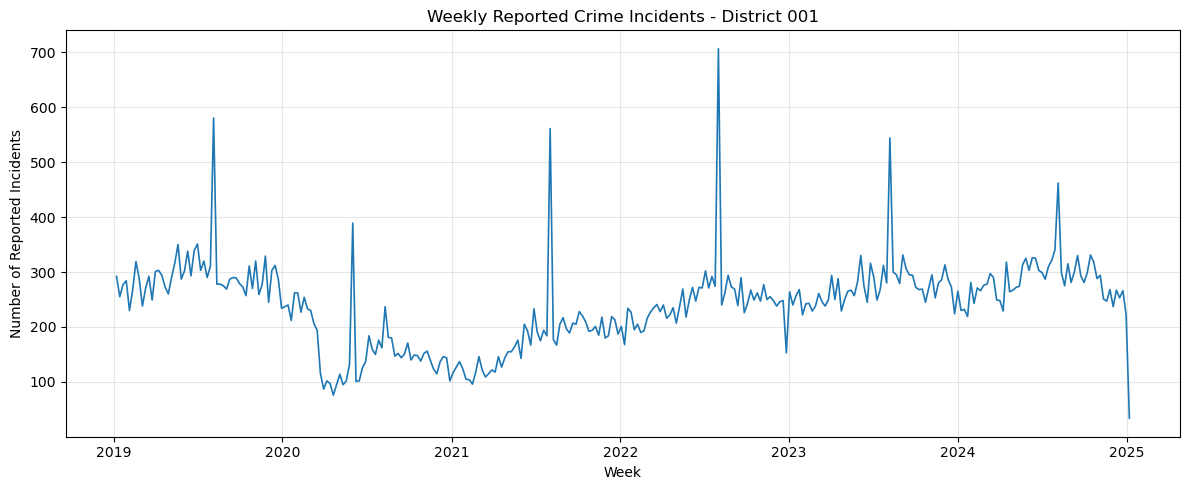

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y_primary.index, y_primary.values, linewidth=1.2)
ax.set_title(f"Weekly Reported Crime Incidents - District {primary}")
ax.set_xlabel("Week")
ax.set_ylabel("Number of Reported Incidents")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

### Rolling Statistics Plot — Primary District

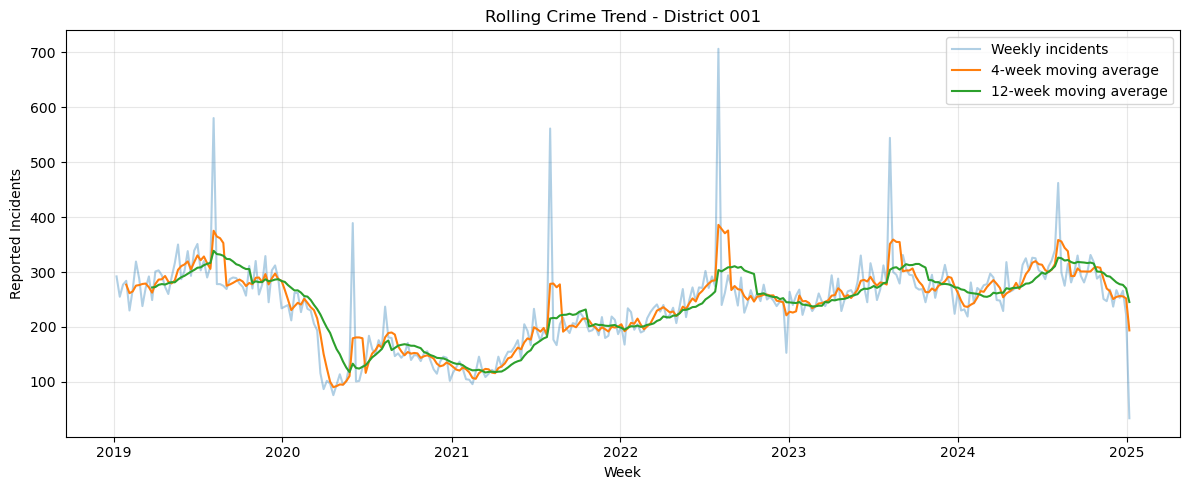

In [9]:
rolling_4_primary = y_primary.rolling(4).mean()
rolling_12_primary = y_primary.rolling(12).mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y_primary.index, y_primary.values, alpha=0.35, label="Weekly incidents")
ax.plot(rolling_4_primary.index, rolling_4_primary, label="4-week moving average")
ax.plot(rolling_12_primary.index, rolling_12_primary, label="12-week moving average")
ax.set_title(f"Rolling Crime Trend - District {primary}")
ax.set_xlabel("Week")
ax.set_ylabel("Reported Incidents")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

### Monthly Distribution Plot — Primary District

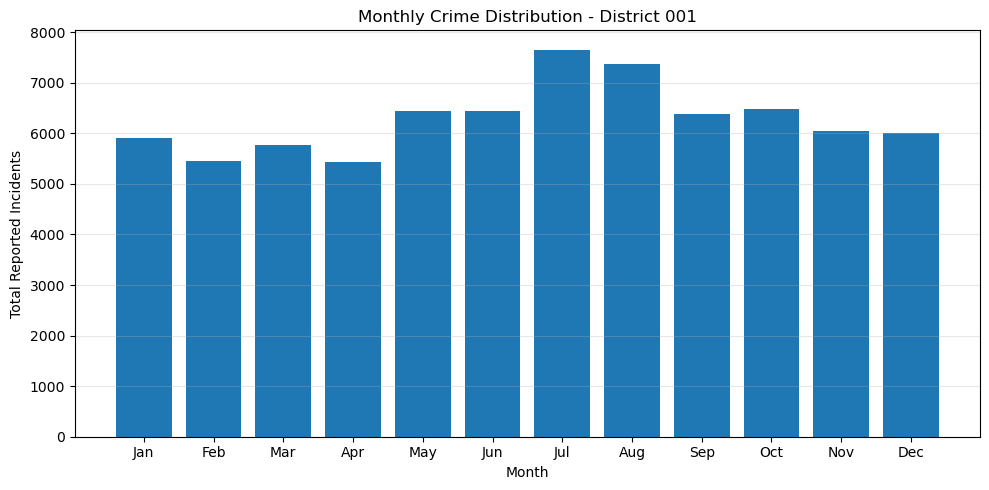

In [10]:
temp_primary = df_primary.copy()
temp_primary["month"] = temp_primary[CONFIG["date_col"]].dt.month
monthly_primary = temp_primary.groupby("month").size().reindex(range(1, 13), fill_value=0)

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(month_names, monthly_primary.values)
ax.set_title(f"Monthly Crime Distribution - District {primary}")
ax.set_xlabel("Month")
ax.set_ylabel("Total Reported Incidents")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

### Yearly Distribution Plot — Primary District

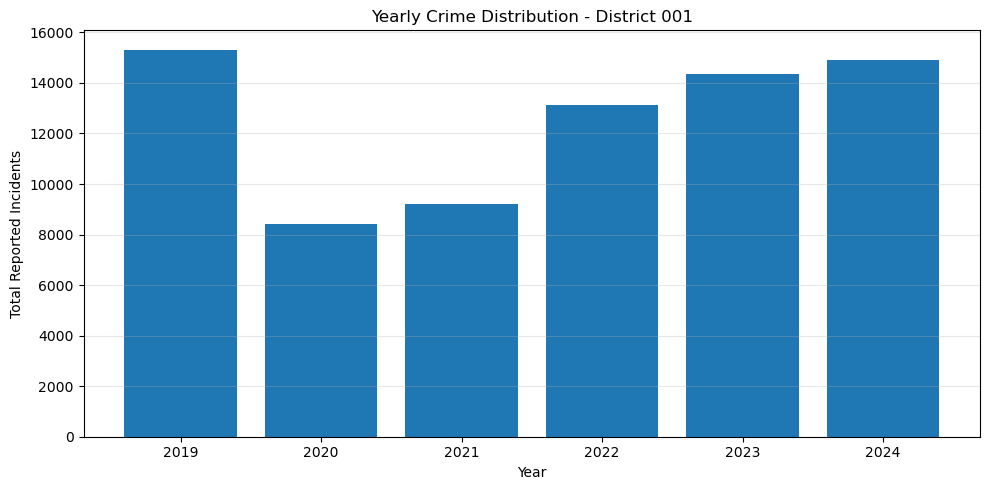

In [11]:
temp_primary["year"] = temp_primary[CONFIG["date_col"]].dt.year
yearly_primary = temp_primary.groupby("year").size()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(yearly_primary.index.astype(str), yearly_primary.values)
ax.set_title(f"Yearly Crime Distribution - District {primary}")
ax.set_xlabel("Year")
ax.set_ylabel("Total Reported Incidents")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

### Month-Year Heatmap — Primary District

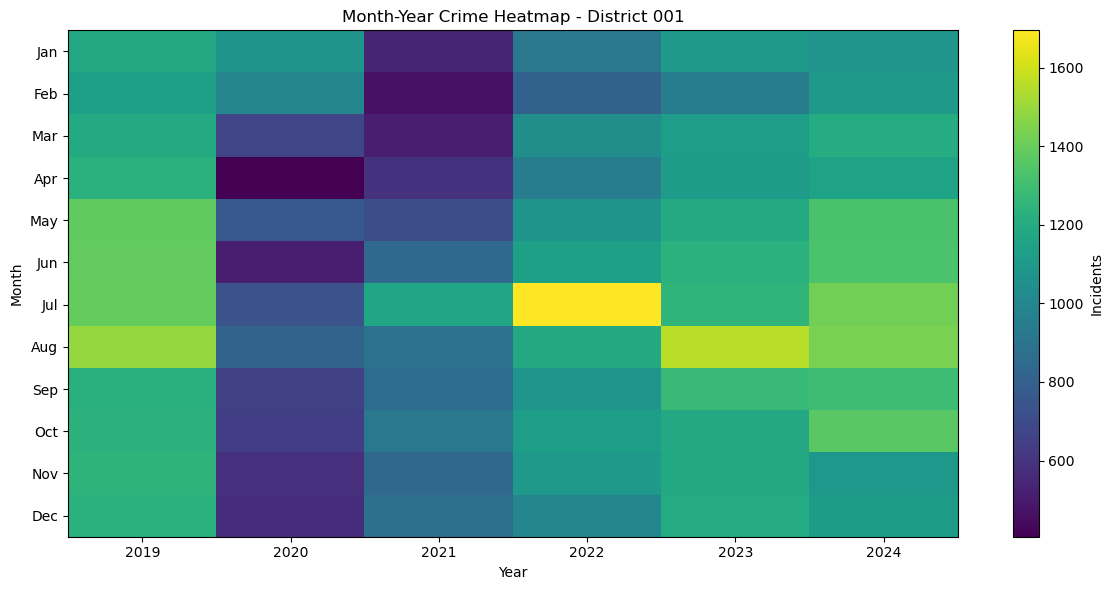

In [12]:
table_primary = temp_primary.pivot_table(
    index="month", columns="year", values=CONFIG["date_col"], aggfunc="size", fill_value=0,
)

fig, ax = plt.subplots(figsize=(12, 6))
image = ax.imshow(table_primary.values, aspect="auto")
fig.colorbar(image, ax=ax, label="Incidents")
ax.set_yticks(range(12))
ax.set_yticklabels(month_names)
ax.set_xticks(range(len(table_primary.columns)))
ax.set_xticklabels(table_primary.columns)
ax.set_title(f"Month-Year Crime Heatmap - District {primary}")
ax.set_xlabel("Year")
ax.set_ylabel("Month")
fig.tight_layout()
plt.show()

### Train/Test Split — Primary District

In [13]:
H = CONFIG["test_periods"]
train_primary = y_primary.iloc[:-H]
test_primary = y_primary.iloc[-H:]

print(f"Training observations: {len(train_primary)}")
print(f"Testing observations: {len(test_primary)}")

Training observations: 302
Testing observations: 12


### Train/Test Plot — Primary District

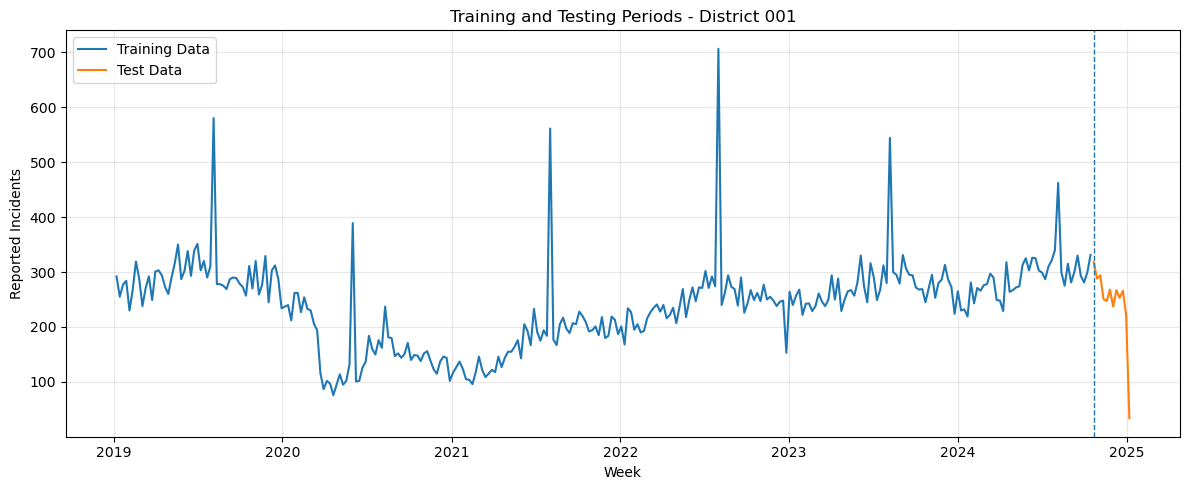

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_primary.index, train_primary.values, label="Training Data")
ax.plot(test_primary.index, test_primary.values, label="Test Data")
ax.axvline(test_primary.index[0], linestyle="--", linewidth=1)
ax.set_title(f"Training and Testing Periods - District {primary}")
ax.set_xlabel("Week")
ax.set_ylabel("Reported Incidents")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

### Augmented Dickey-Fuller Stationarity Test — Primary District

In [15]:
adf_stat_primary, adf_p_primary, *_ = adfuller(train_primary)
print(f"ADF statistic = {adf_stat_primary:.4f}")
print(f"ADF p-value = {adf_p_primary:.6f}")
print("Conclusion:", "Evidence of stationarity." if adf_p_primary < 0.05 else "Evidence of non-stationarity.")

ADF statistic = -2.3483
ADF p-value = 0.156854
Conclusion: Evidence of non-stationarity.


### ACF / PACF Plots — Primary District

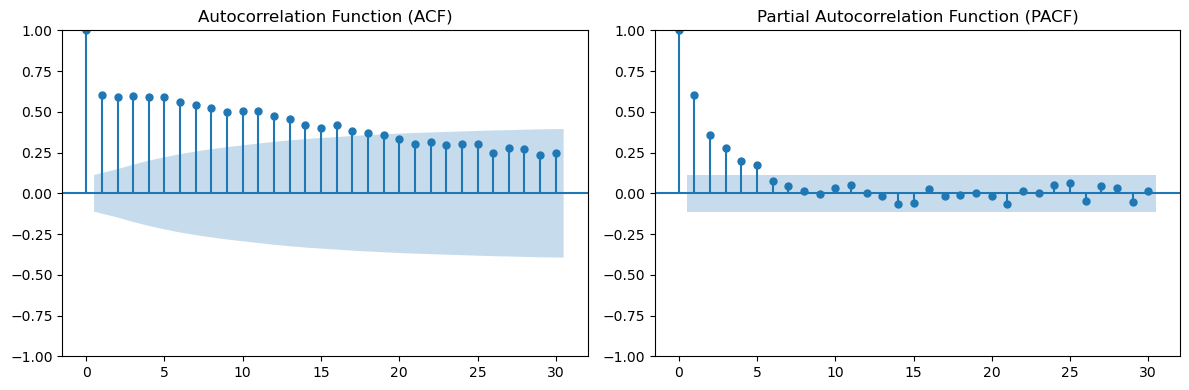

In [16]:
lag_value_primary = min(30, max(1, len(train_primary) // 4))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(train_primary, lags=lag_value_primary, ax=ax[0])
plot_pacf(train_primary, lags=lag_value_primary, ax=ax[1], method="ywm")
ax[0].set_title("Autocorrelation Function (ACF)")
ax[1].set_title("Partial Autocorrelation Function (PACF)")
fig.tight_layout()
plt.show()

### Naive Baseline — Primary District

In [17]:
naive_pred_primary = np.repeat(train_primary.iloc[-1], len(test_primary))
naive_score_primary = {
    "MAE": float(mean_absolute_error(test_primary, naive_pred_primary)),
    "RMSE": float(mean_squared_error(test_primary, naive_pred_primary) ** 0.5),
}
print("Naive baseline:", naive_score_primary)

Naive baseline: {'MAE': 85.58333333333333, 'RMSE': 109.59888989705446}


### AR(4) Model — Primary District

In [18]:
ar_model_primary = AutoReg(train_primary, lags=CONFIG["ar_lags"], trend="ct").fit()
ar_pred_primary = ar_model_primary.predict(
    start=len(train_primary), end=len(train_primary) + len(test_primary) - 1, dynamic=False,
)
ar_score_primary = {
    "MAE": float(mean_absolute_error(test_primary, ar_pred_primary)),
    "RMSE": float(mean_squared_error(test_primary, ar_pred_primary) ** 0.5),
}
print(f"AR({CONFIG['ar_lags']}):", ar_score_primary)

AR(4): {'MAE': 58.609849061181116, 'RMSE': 87.62740038304158}


### ARIMA Candidate Selection — Primary District

In [19]:
arima_rows_primary = []
for order in CONFIG["arima_candidates"]:
    try:
        model = ARIMA(train_primary, order=order).fit()
        arima_rows_primary.append({"order": order, "AIC": model.aic, "model": model})
        print(f"  ARIMA{order} -> AIC = {model.aic:.2f}")
    except Exception as exc:
        print(f"  ARIMA{order} failed: {exc}")

if not arima_rows_primary:
    raise RuntimeError("All ARIMA models failed.")

best_primary = min(arima_rows_primary, key=lambda x: x["AIC"])
print(f"Best ARIMA model: {best_primary['order']}")
print(f"Best AIC: {best_primary['AIC']:.2f}")

arima_model_primary = best_primary["model"]
arima_pred_primary = arima_model_primary.forecast(steps=len(test_primary))
arima_score_primary = {
    "MAE": float(mean_absolute_error(test_primary, arima_pred_primary)),
    "RMSE": float(mean_squared_error(test_primary, arima_pred_primary) ** 0.5),
}
print(f"ARIMA{best_primary['order']}:", arima_score_primary)

  ARIMA(1, 0, 0) -> AIC = 3354.84
  ARIMA(2, 0, 0) -> AIC = 3314.55
  ARIMA(1, 1, 1) -> AIC = 3257.76
  ARIMA(2, 1, 1) -> AIC = 3258.92
Best ARIMA model: (1, 1, 1)
Best AIC: 3257.76
ARIMA(1, 1, 1): {'MAE': 64.49940275669104, 'RMSE': 92.89817819205737}


### Model Comparison Table — Primary District

In [20]:
results_primary = pd.DataFrame([
    {"Model": "Naive", **naive_score_primary},
    {"Model": f"AR({CONFIG['ar_lags']})", **ar_score_primary},
    {"Model": f"ARIMA{best_primary['order']}", **arima_score_primary},
]).sort_values("MAE")

print(results_primary.to_string(index=False))

         Model       MAE       RMSE
         AR(4) 58.609849  87.627400
ARIMA(1, 1, 1) 64.499403  92.898178
         Naive 85.583333 109.598890


### Model Performance Plot (MAE) — Primary District

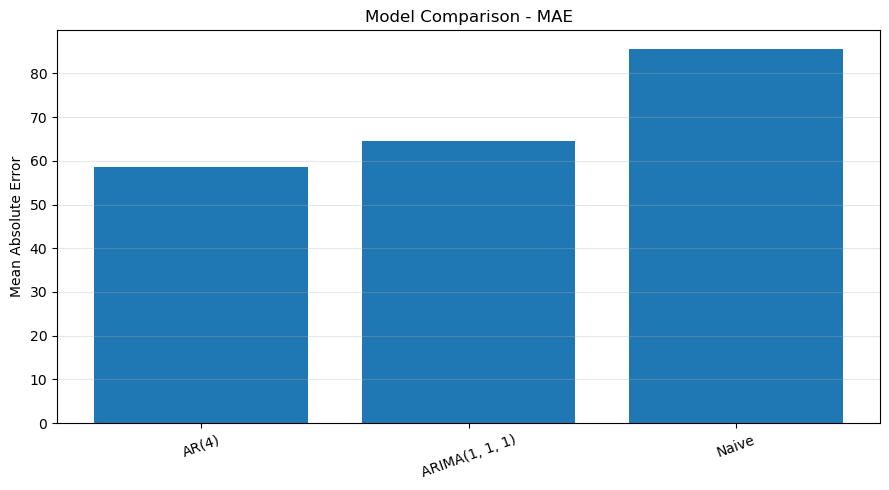

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(results_primary["Model"], results_primary["MAE"])
ax.set_title("Model Comparison - MAE")
ax.set_ylabel("Mean Absolute Error")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

### Model Performance Plot (RMSE) — Primary District

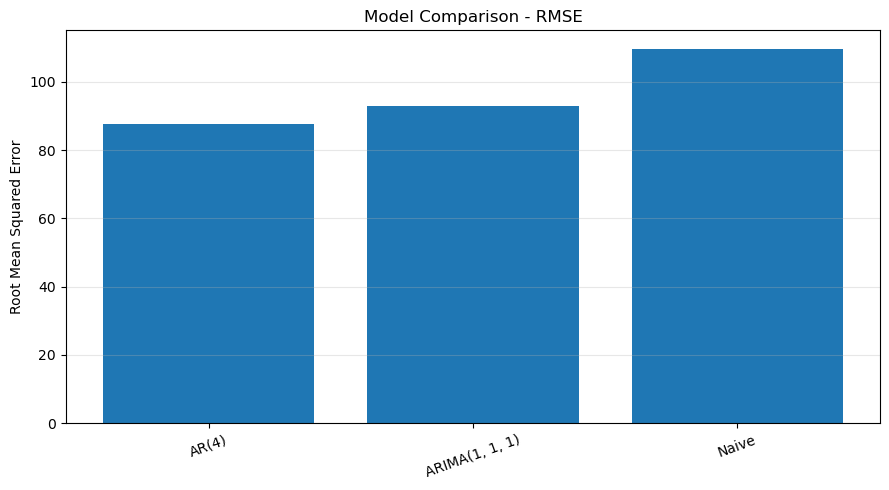

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(results_primary["Model"], results_primary["RMSE"])
ax.set_title("Model Comparison - RMSE")
ax.set_ylabel("Root Mean Squared Error")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

### Actual vs Forecasted Plot — Primary District

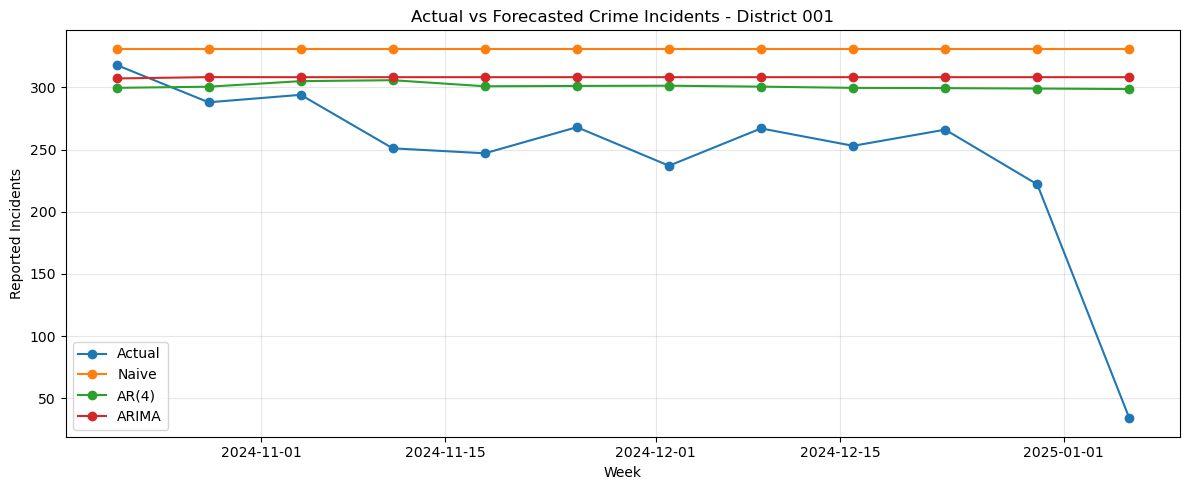

In [23]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_primary.index, test_primary.values, marker="o", label="Actual")
ax.plot(test_primary.index, naive_pred_primary, marker="o", label="Naive")
ax.plot(test_primary.index, ar_pred_primary, marker="o", label="AR(4)")
ax.plot(test_primary.index, arima_pred_primary, marker="o", label="ARIMA")
ax.set_title(f"Actual vs Forecasted Crime Incidents - District {primary}")
ax.set_xlabel("Week")
ax.set_ylabel("Reported Incidents")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

### ARIMA Forecast with 95% Prediction Interval — Primary District

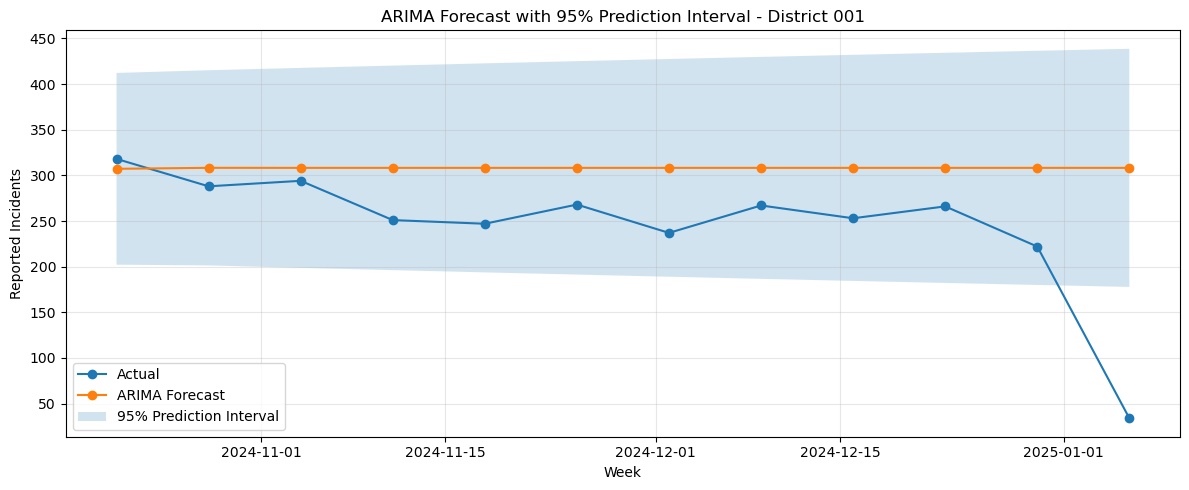

95% prediction interval coverage: 91.67%


In [24]:
forecast_result_primary = arima_model_primary.get_forecast(steps=len(test_primary))
prediction_primary = forecast_result_primary.predicted_mean
ci_primary = forecast_result_primary.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_primary.index, test_primary.values, marker="o", label="Actual")
ax.plot(prediction_primary.index, prediction_primary.values, marker="o", label="ARIMA Forecast")
ax.fill_between(
    prediction_primary.index, ci_primary.iloc[:, 0].values, ci_primary.iloc[:, 1].values,
    alpha=0.2, label="95% Prediction Interval",
)
ax.set_title(f"ARIMA Forecast with 95% Prediction Interval - District {primary}")
ax.set_xlabel("Week")
ax.set_ylabel("Reported Incidents")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

coverage_primary = float((
    (test_primary.values >= ci_primary.iloc[:, 0].values) &
    (test_primary.values <= ci_primary.iloc[:, 1].values)
).mean())
print(f"95% prediction interval coverage: {coverage_primary:.2%}")

### Residuals Over Time — Primary District

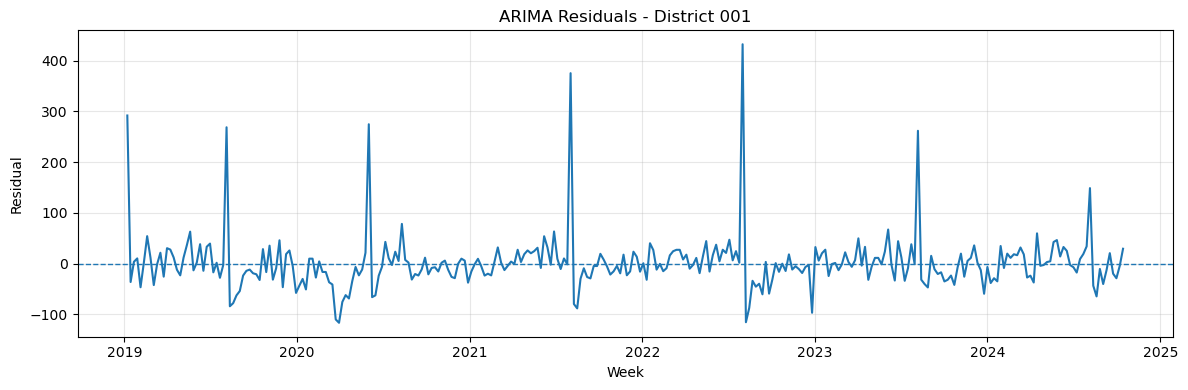

In [25]:
residuals_primary = arima_model_primary.resid.dropna()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(residuals_primary.index, residuals_primary.values)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title(f"ARIMA Residuals - District {primary}")
ax.set_xlabel("Week")
ax.set_ylabel("Residual")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

### Residual Distribution — Primary District

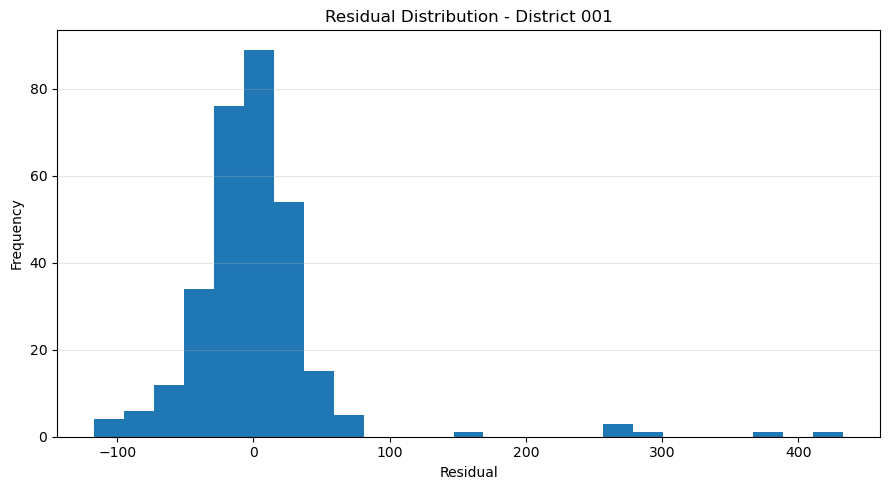

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(residuals_primary, bins=25)
ax.set_title(f"Residual Distribution - District {primary}")
ax.set_xlabel("Residual")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

### Residual Autocorrelation — Primary District

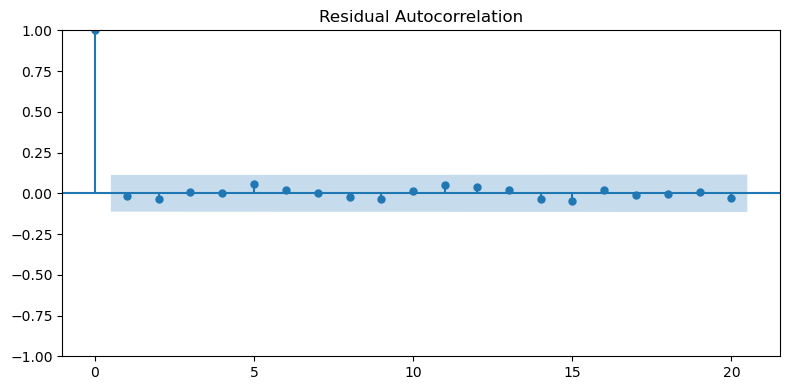

In [27]:
lag_value_resid_primary = min(20, max(1, len(residuals_primary) // 3))
fig, ax = plt.subplots(figsize=(8, 4))
plot_acf(residuals_primary, lags=lag_value_resid_primary, ax=ax)
ax.set_title("Residual Autocorrelation")
fig.tight_layout()
plt.show()

### Ljung-Box Test on Residuals — Primary District

In [28]:
lb_lag_primary = min(10, max(2, len(residuals_primary) // 10))
lb_primary = acorr_ljungbox(residuals_primary, lags=[lb_lag_primary], return_df=True)
lb_p_primary = float(lb_primary["lb_pvalue"].iloc[0])

print(f"Ljung-Box test (lag={lb_lag_primary}):")
print(lb_primary)
print("Conclusion:", "Residuals show significant autocorrelation." if lb_p_primary < 0.05 else "No strong evidence of remaining autocorrelation.")

Ljung-Box test (lag=10):
     lb_stat  lb_pvalue
10  2.230273   0.994251
Conclusion: No strong evidence of remaining autocorrelation.


### Rolling-Origin Backtest — Primary District

In [29]:
rolling_rows_primary = []
initial_primary = max(52, len(train_primary) // 2)
end_primary = initial_primary
fold_primary = 0

while end_primary + CONFIG["rolling_horizon"] <= len(train_primary):
    fold_primary += 1
    fold_train_primary = train_primary.iloc[:end_primary]
    fold_test_primary = train_primary.iloc[end_primary:end_primary + CONFIG["rolling_horizon"]]
    try:
        fold_model_primary = ARIMA(fold_train_primary, order=best_primary["order"]).fit()
        fold_pred_primary = fold_model_primary.forecast(len(fold_test_primary))
        rolling_rows_primary.append({
            "fold": fold_primary,
            "MAE": float(mean_absolute_error(fold_test_primary, fold_pred_primary)),
            "RMSE": float(mean_squared_error(fold_test_primary, fold_pred_primary) ** 0.5),
        })
    except Exception as exc:
        print(f"Fold {fold_primary} failed: {exc}")
    end_primary += CONFIG["rolling_step"]

rolling_df_primary = pd.DataFrame(rolling_rows_primary)

if len(rolling_df_primary):
    print(rolling_df_primary.to_string(index=False))
    print("Rolling validation summary:")
    print(rolling_df_primary[["MAE", "RMSE"]].agg(["mean", "std"]))

 fold       MAE       RMSE
    1 19.128098  21.598510
    2 16.023031  18.764477
    3 14.788541  17.123232
    4 38.825792  43.544299
    5 66.729175 155.459183
    6 51.986045  55.284094
    7 13.894493  14.598807
    8 23.532845  36.915468
    9 13.993636  20.642883
   10 23.602294  32.242189
   11 19.994737  24.480487
   12 49.017739  94.958790
   13 37.613484  40.244397
   14 26.341490  32.052032
   15 24.723741  26.907339
   16 21.646114  26.548503
   17 38.907296  42.297414
   18 34.727842  58.745420
Rolling validation summary:
            MAE       RMSE
mean  29.748688  42.355974
std   14.921190  34.225194


### Auxiliary High/Low Crime Classification — Primary District

AUXILIARY HIGH/LOW CRIME CLASSIFICATION - District 001
Classification threshold (training median): 248.00
Confusion Matrix:
[[0 4]
 [0 8]]
Classification Report:
              precision    recall  f1-score   support

   Low Crime       0.00      0.00      0.00         4
  High Crime       0.67      1.00      0.80         8

    accuracy                           0.67        12
   macro avg       0.33      0.50      0.40        12
weighted avg       0.44      0.67      0.53        12



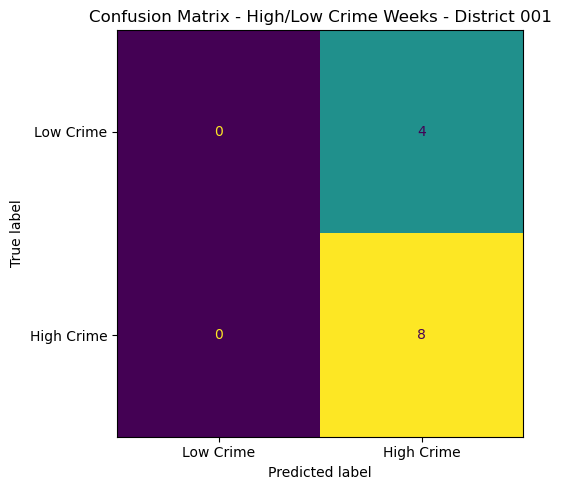

In [30]:
threshold_primary = float(train_primary.median())

actual_class_primary = (np.asarray(test_primary) >= threshold_primary).astype(int)
predicted_class_primary = (np.asarray(arima_pred_primary) >= threshold_primary).astype(int)

cm_primary = confusion_matrix(actual_class_primary, predicted_class_primary, labels=[0, 1])
classification_report_primary = classification_report(
    actual_class_primary, predicted_class_primary, labels=[0, 1],
    target_names=["Low Crime", "High Crime"], zero_division=0,
)

print(f"AUXILIARY HIGH/LOW CRIME CLASSIFICATION - District {primary}")
print(f"Classification threshold (training median): {threshold_primary:.2f}")
print("Confusion Matrix:")
print(cm_primary)
print("Classification Report:")
print(classification_report_primary)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_primary, display_labels=["Low Crime", "High Crime"]).plot(
    ax=ax, values_format="d", colorbar=False,
)
ax.set_title(f"Confusion Matrix - High/Low Crime Weeks - District {primary}")
fig.tight_layout()
plt.show()

### Save Outputs to Disk — Primary District

In [31]:
suffix_primary = f"district{primary}"

results_primary.to_csv(OUT / f"model_comparison_{suffix_primary}.csv", index=False)

pred_df_primary = pd.DataFrame(
    {
        "actual": test_primary.values,
        "naive": np.asarray(naive_pred_primary),
        "AR": np.asarray(ar_pred_primary),
        "ARIMA": np.asarray(arima_pred_primary),
    },
    index=test_primary.index,
)
pred_df_primary.to_csv(OUT / f"test_predictions_{suffix_primary}.csv")

if len(rolling_df_primary):
    rolling_df_primary.to_csv(OUT / f"rolling_origin_{suffix_primary}.csv", index=False)

manifest_primary = {
    "dataset": CONFIG["dataset_name"],
    "district": primary,
    "start_date": CONFIG["start_date"],
    "end_date": CONFIG["end_date"],
    "frequency": CONFIG["frequency"],
    "n_total_periods": len(y_primary),
    "n_train": len(train_primary),
    "n_test": len(test_primary),
    "ADF_statistic": float(adf_stat_primary),
    "ADF_pvalue": float(adf_p_primary),
    "selected_ARIMA_order": list(best_primary["order"]),
    "selected_ARIMA_AIC": float(best_primary["AIC"]),
    "Ljung_Box_pvalue": lb_p_primary,
    "prediction_interval_coverage": coverage_primary,
    "classification_threshold": threshold_primary,
    "confusion_matrix": cm_primary.tolist(),
    "python": sys.version,
    "platform": platform.platform(),
}

(OUT / f"manifest_{suffix_primary}.json").write_text(
    json.dumps(manifest_primary, indent=2, default=str), encoding="utf-8",
)

print(f"Outputs for district {primary} saved.")

Outputs for district 001 saved.


# Full Pipeline — Second (Replication) District (`second`)

### Fetch Crime Records — Second (Replication) District

In [32]:
where_second = (
    f"district = '{second}' "
    f"AND date >= '{CONFIG['start_date']}T00:00:00' "
    f"AND date <= '{CONFIG['end_date']}T23:59:59'"
)
select_cols_second = ",".join([CONFIG["date_col"], CONFIG["location_col"], CONFIG["category_col"], "case_number"])

records_second = []
limit_second = 50000
offset_second = 0

print(f"Fetching data for district {second}...")

while len(records_second) < CONFIG["max_rows_per_location"]:
    params = {
        "$select": select_cols_second,
        "$where": where_second,
        "$order": f"{CONFIG['date_col']} ASC",
        "$limit": min(limit_second, CONFIG["max_rows_per_location"] - len(records_second)),
        "$offset": offset_second,
    }
    print(f"  Downloading rows {offset_second:,}...")
    response = requests.get(CONFIG["soda_endpoint"], params=params, timeout=60)
    response.raise_for_status()
    batch = response.json()
    if not batch:
        break
    records_second.extend(batch)
    offset_second += len(batch)
    if len(batch) < limit_second:
        break
    time.sleep(0.2)

if not records_second:
    raise ValueError(f"No crime records found for district {second}.")

raw_second = pd.DataFrame(records_second)
print(f"  Retrieved {len(raw_second):,} rows.")

Fetching data for district 012...
  Retrieved 80,995 rows.


### Validate and Clean — Second (Replication) District

In [33]:
print("DATASET PREVIEW")
print(raw_second.head())

print("DATASET SHAPE:", raw_second.shape)
print("COLUMN NAMES:", raw_second.columns.tolist())

required_second = {CONFIG["date_col"], CONFIG["location_col"]}
missing_cols_second = required_second - set(raw_second.columns)
if missing_cols_second:
    raise ValueError(f"Missing required columns: {missing_cols_second}")

df_second = raw_second.copy()
df_second[CONFIG["date_col"]] = pd.to_datetime(df_second[CONFIG["date_col"]], errors="coerce")
before_second = len(df_second)
df_second = df_second.dropna(subset=[CONFIG["date_col"]]).copy()
print(f"Valid timestamps: {len(df_second):,}/{before_second:,}")

if "case_number" in df_second.columns:
    duplicates_second = df_second.duplicated(subset=["case_number"]).sum()
    print(f"Duplicate case numbers: {duplicates_second:,}")
    if duplicates_second:
        df_second = df_second.drop_duplicates(subset=["case_number"])

df_second[CONFIG["location_col"]] = df_second[CONFIG["location_col"]].astype(str).str.strip().str.zfill(3)

print("CLEANED DATASET HEAD")
print(df_second.head())

DATASET PREVIEW
                      date district                primary_type case_number
0  2019-01-01T00:00:00.000      012               OTHER OFFENSE    JE341674
1  2019-01-01T00:00:00.000      012                 SEX OFFENSE    JD110337
2  2019-01-01T00:00:00.000      012                       THEFT    JE476412
3  2019-01-01T00:00:00.000      012  OFFENSE INVOLVING CHILDREN    JC323472
4  2019-01-01T00:00:00.000      012                    BURGLARY    JJ356665
DATASET SHAPE: (80995, 4)
COLUMN NAMES: ['date', 'district', 'primary_type', 'case_number']
Valid timestamps: 80,995/80,995
Duplicate case numbers: 7
CLEANED DATASET HEAD
        date district                primary_type case_number
0 2019-01-01      012               OTHER OFFENSE    JE341674
1 2019-01-01      012                 SEX OFFENSE    JD110337
2 2019-01-01      012                       THEFT    JE476412
3 2019-01-01      012  OFFENSE INVOLVING CHILDREN    JC323472
4 2019-01-01      012                    BURGLA

### Data Quality Plot — Second (Replication) District

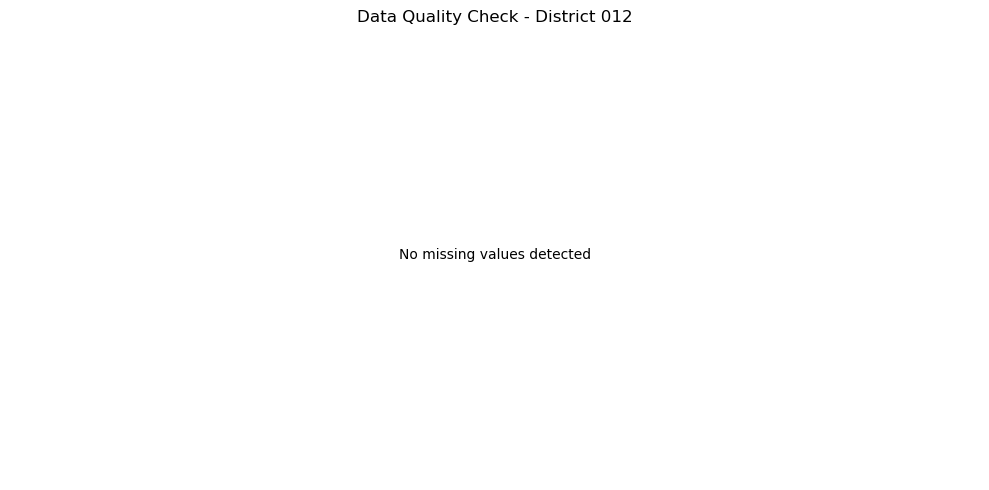

In [34]:
missing_second = df_second.isna().sum()
missing_second = missing_second[missing_second > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
if len(missing_second):
    missing_second.plot(kind="bar", ax=ax)
    ax.set_ylabel("Missing Values")
    ax.set_title(f"Missing Values - District {second}")
else:
    ax.text(0.5, 0.5, "No missing values detected", ha="center", va="center")
    ax.set_title(f"Data Quality Check - District {second}")
    ax.set_axis_off()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

### Build Weekly Time Series — Second (Replication) District

In [35]:
loc_second = df_second[df_second[CONFIG["location_col"]] == second].copy()
if len(loc_second) == 0:
    raise ValueError(f"No observations for district {second}")

y_second = (
    loc_second.set_index(CONFIG["date_col"])
    .resample(CONFIG["frequency"])
    .size()
    .rename("incidents")
    .asfreq(CONFIG["frequency"], fill_value=0)
)

print(y_second.describe())

count    314.000000
mean     257.923567
std       59.398964
min       47.000000
25%      214.000000
50%      261.000000
75%      302.000000
max      394.000000
Name: incidents, dtype: float64


### Weekly Trend Plot — Second (Replication) District

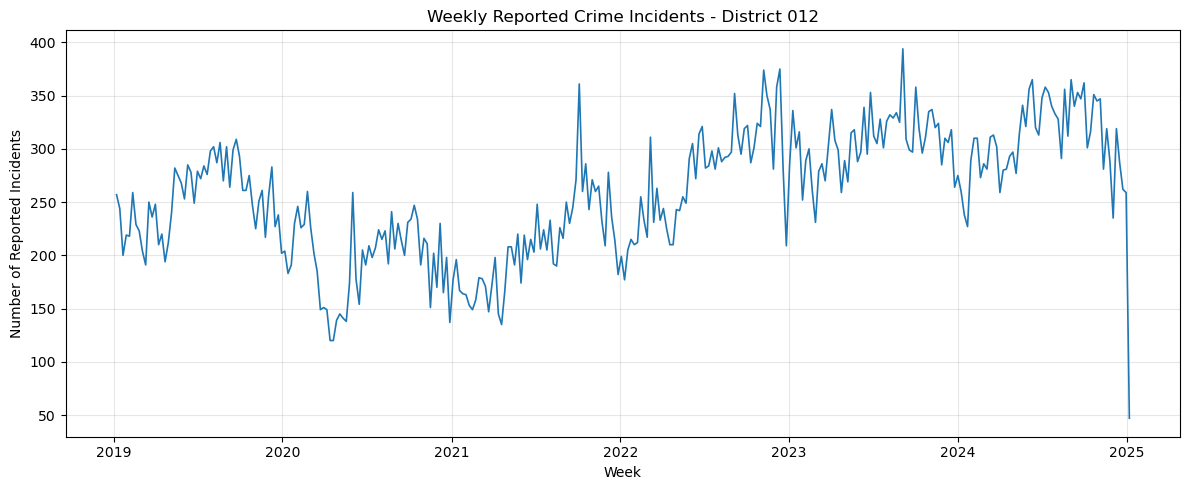

In [36]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y_second.index, y_second.values, linewidth=1.2)
ax.set_title(f"Weekly Reported Crime Incidents - District {second}")
ax.set_xlabel("Week")
ax.set_ylabel("Number of Reported Incidents")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

### Rolling Statistics Plot — Second (Replication) District

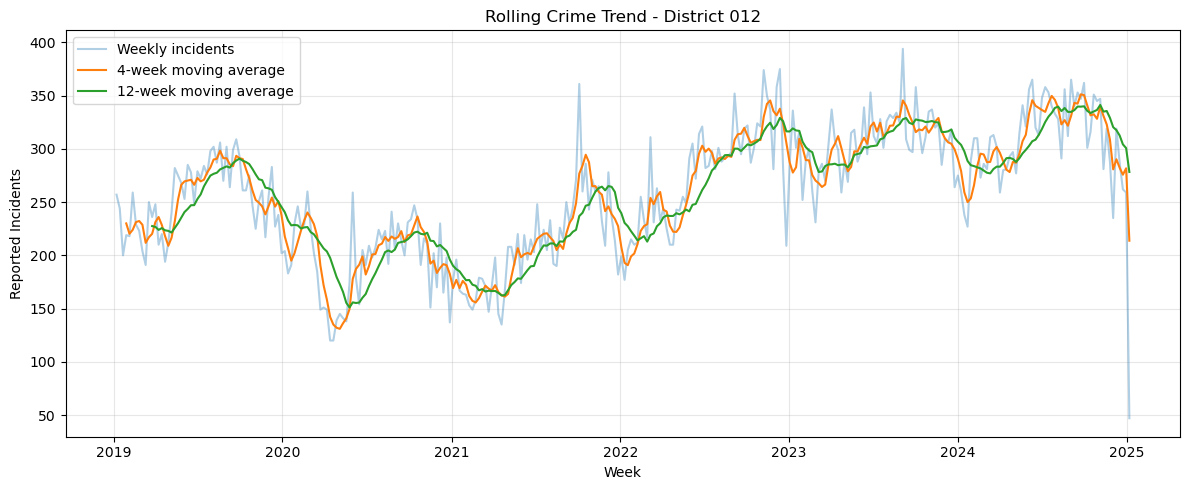

In [37]:
rolling_4_second = y_second.rolling(4).mean()
rolling_12_second = y_second.rolling(12).mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y_second.index, y_second.values, alpha=0.35, label="Weekly incidents")
ax.plot(rolling_4_second.index, rolling_4_second, label="4-week moving average")
ax.plot(rolling_12_second.index, rolling_12_second, label="12-week moving average")
ax.set_title(f"Rolling Crime Trend - District {second}")
ax.set_xlabel("Week")
ax.set_ylabel("Reported Incidents")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

### Monthly Distribution Plot — Second (Replication) District

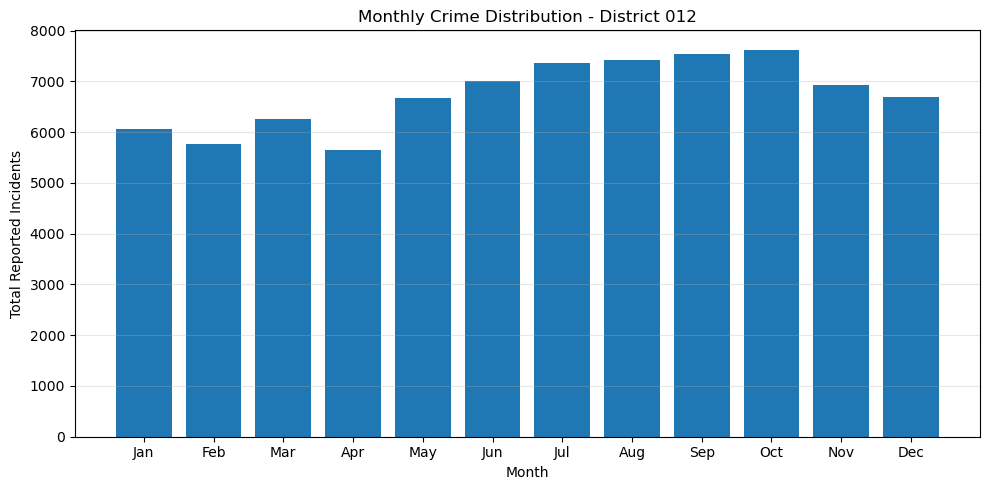

In [38]:
temp_second = df_second.copy()
temp_second["month"] = temp_second[CONFIG["date_col"]].dt.month
monthly_second = temp_second.groupby("month").size().reindex(range(1, 13), fill_value=0)

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(month_names, monthly_second.values)
ax.set_title(f"Monthly Crime Distribution - District {second}")
ax.set_xlabel("Month")
ax.set_ylabel("Total Reported Incidents")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

### Yearly Distribution Plot — Second (Replication) District

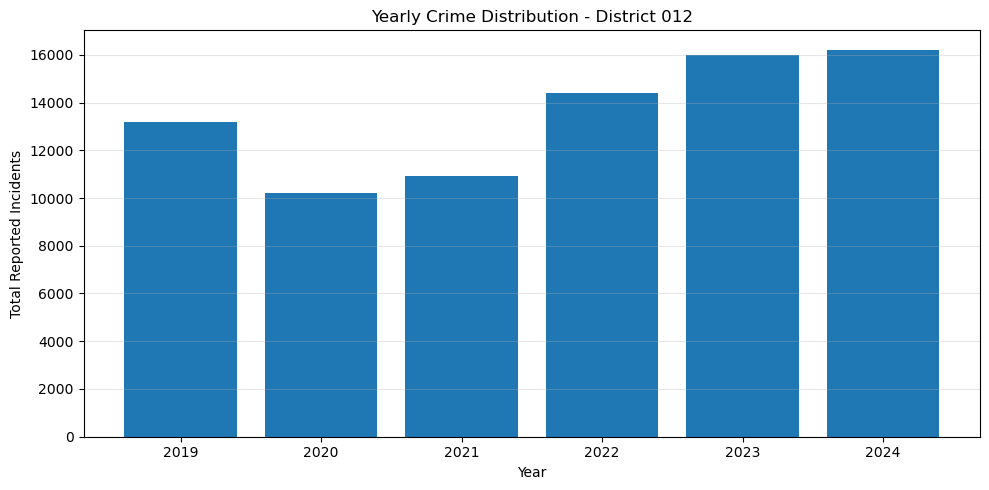

In [39]:
temp_second["year"] = temp_second[CONFIG["date_col"]].dt.year
yearly_second = temp_second.groupby("year").size()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(yearly_second.index.astype(str), yearly_second.values)
ax.set_title(f"Yearly Crime Distribution - District {second}")
ax.set_xlabel("Year")
ax.set_ylabel("Total Reported Incidents")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

### Month-Year Heatmap — Second (Replication) District

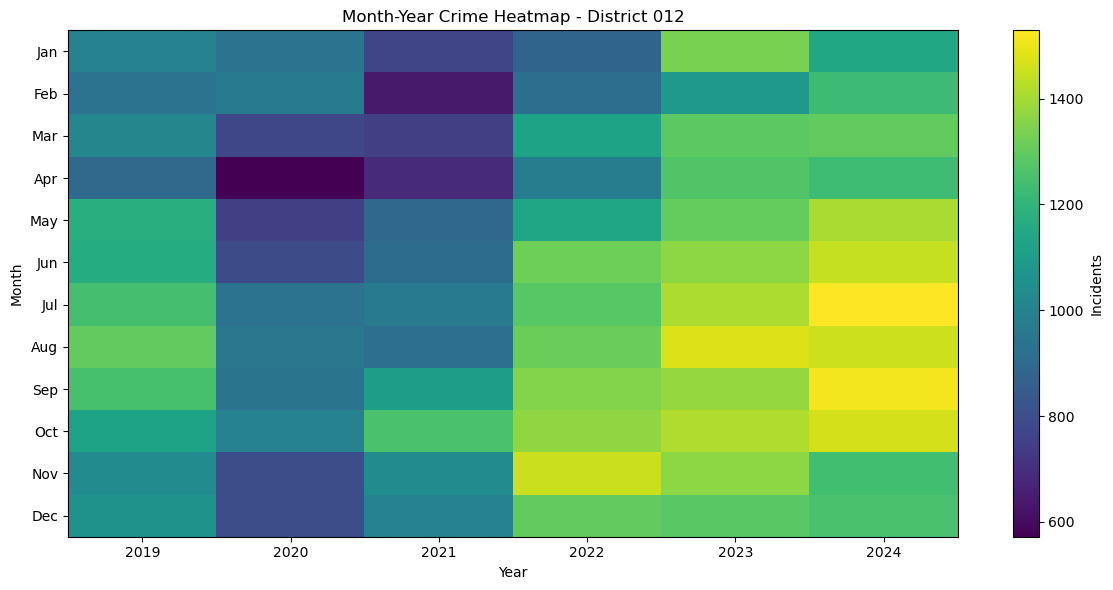

In [40]:
table_second = temp_second.pivot_table(
    index="month", columns="year", values=CONFIG["date_col"], aggfunc="size", fill_value=0,
)

fig, ax = plt.subplots(figsize=(12, 6))
image = ax.imshow(table_second.values, aspect="auto")
fig.colorbar(image, ax=ax, label="Incidents")
ax.set_yticks(range(12))
ax.set_yticklabels(month_names)
ax.set_xticks(range(len(table_second.columns)))
ax.set_xticklabels(table_second.columns)
ax.set_title(f"Month-Year Crime Heatmap - District {second}")
ax.set_xlabel("Year")
ax.set_ylabel("Month")
fig.tight_layout()
plt.show()

### Train/Test Split — Second (Replication) District

In [41]:
H = CONFIG["test_periods"]
train_second = y_second.iloc[:-H]
test_second = y_second.iloc[-H:]

print(f"Training observations: {len(train_second)}")
print(f"Testing observations: {len(test_second)}")

Training observations: 302
Testing observations: 12


### Train/Test Plot — Second (Replication) District

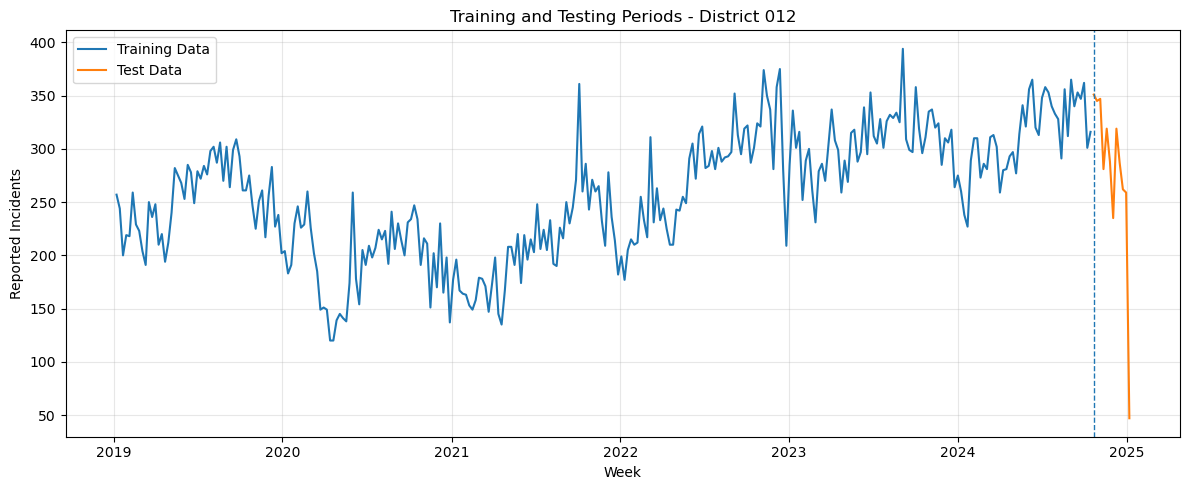

In [42]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_second.index, train_second.values, label="Training Data")
ax.plot(test_second.index, test_second.values, label="Test Data")
ax.axvline(test_second.index[0], linestyle="--", linewidth=1)
ax.set_title(f"Training and Testing Periods - District {second}")
ax.set_xlabel("Week")
ax.set_ylabel("Reported Incidents")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

### Augmented Dickey-Fuller Stationarity Test — Second (Replication) District

In [43]:
adf_stat_second, adf_p_second, *_ = adfuller(train_second)
print(f"ADF statistic = {adf_stat_second:.4f}")
print(f"ADF p-value = {adf_p_second:.6f}")
print("Conclusion:", "Evidence of stationarity." if adf_p_second < 0.05 else "Evidence of non-stationarity.")

ADF statistic = -1.9854
ADF p-value = 0.292992
Conclusion: Evidence of non-stationarity.


### ACF / PACF Plots — Second (Replication) District

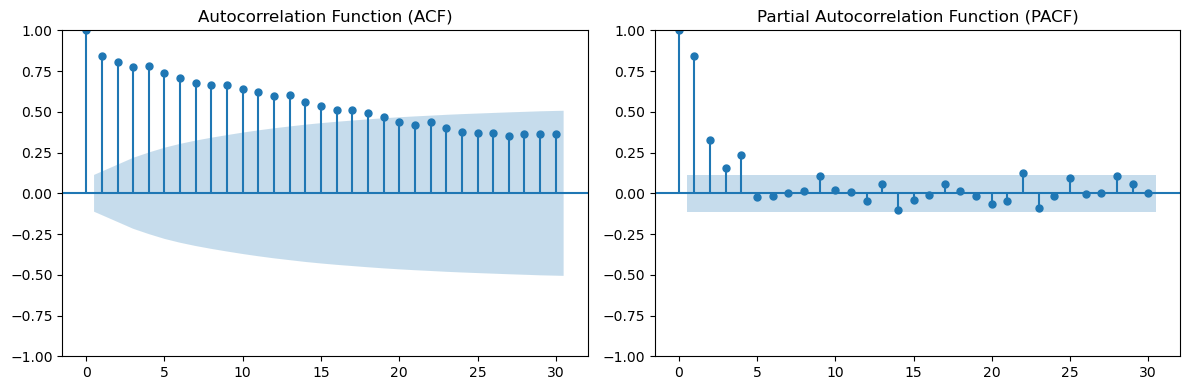

In [44]:
lag_value_second = min(30, max(1, len(train_second) // 4))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(train_second, lags=lag_value_second, ax=ax[0])
plot_pacf(train_second, lags=lag_value_second, ax=ax[1], method="ywm")
ax[0].set_title("Autocorrelation Function (ACF)")
ax[1].set_title("Partial Autocorrelation Function (PACF)")
fig.tight_layout()
plt.show()

### Naive Baseline — Second (Replication) District

In [45]:
naive_pred_second = np.repeat(train_second.iloc[-1], len(test_second))
naive_score_second = {
    "MAE": float(mean_absolute_error(test_second, naive_pred_second)),
    "RMSE": float(mean_squared_error(test_second, naive_pred_second) ** 0.5),
}
print("Naive baseline:", naive_score_second)

Naive baseline: {'MAE': 54.5, 'RMSE': 87.07372355270752}


### AR(4) Model — Second (Replication) District

In [46]:
ar_model_second = AutoReg(train_second, lags=CONFIG["ar_lags"], trend="ct").fit()
ar_pred_second = ar_model_second.predict(
    start=len(train_second), end=len(train_second) + len(test_second) - 1, dynamic=False,
)
ar_score_second = {
    "MAE": float(mean_absolute_error(test_second, ar_pred_second)),
    "RMSE": float(mean_squared_error(test_second, ar_pred_second) ** 0.5),
}
print(f"AR({CONFIG['ar_lags']}):", ar_score_second)

AR(4): {'MAE': 58.97032555832832, 'RMSE': 92.77207413673788}


### ARIMA Candidate Selection — Second (Replication) District

In [47]:
arima_rows_second = []
for order in CONFIG["arima_candidates"]:
    try:
        model = ARIMA(train_second, order=order).fit()
        arima_rows_second.append({"order": order, "AIC": model.aic, "model": model})
        print(f"  ARIMA{order} -> AIC = {model.aic:.2f}")
    except Exception as exc:
        print(f"  ARIMA{order} failed: {exc}")

if not arima_rows_second:
    raise RuntimeError("All ARIMA models failed.")

best_second = min(arima_rows_second, key=lambda x: x["AIC"])
print(f"Best ARIMA model: {best_second['order']}")
print(f"Best AIC: {best_second['AIC']:.2f}")

arima_model_second = best_second["model"]
arima_pred_second = arima_model_second.forecast(steps=len(test_second))
arima_score_second = {
    "MAE": float(mean_absolute_error(test_second, arima_pred_second)),
    "RMSE": float(mean_squared_error(test_second, arima_pred_second) ** 0.5),
}
print(f"ARIMA{best_second['order']}:", arima_score_second)

  ARIMA(1, 0, 0) -> AIC = 2940.51
  ARIMA(2, 0, 0) -> AIC = 2908.44
  ARIMA(1, 1, 1) -> AIC = 2878.25
  ARIMA(2, 1, 1) -> AIC = 2880.24
Best ARIMA model: (1, 1, 1)
Best AIC: 2878.25
ARIMA(1, 1, 1): {'MAE': 59.344367351919, 'RMSE': 92.60279959208016}


### Model Comparison Table — Second (Replication) District

In [48]:
results_second = pd.DataFrame([
    {"Model": "Naive", **naive_score_second},
    {"Model": f"AR({CONFIG['ar_lags']})", **ar_score_second},
    {"Model": f"ARIMA{best_second['order']}", **arima_score_second},
]).sort_values("MAE")

print(results_second.to_string(index=False))

         Model       MAE      RMSE
         Naive 54.500000 87.073724
         AR(4) 58.970326 92.772074
ARIMA(1, 1, 1) 59.344367 92.602800


### Model Performance Plot (MAE) — Second (Replication) District

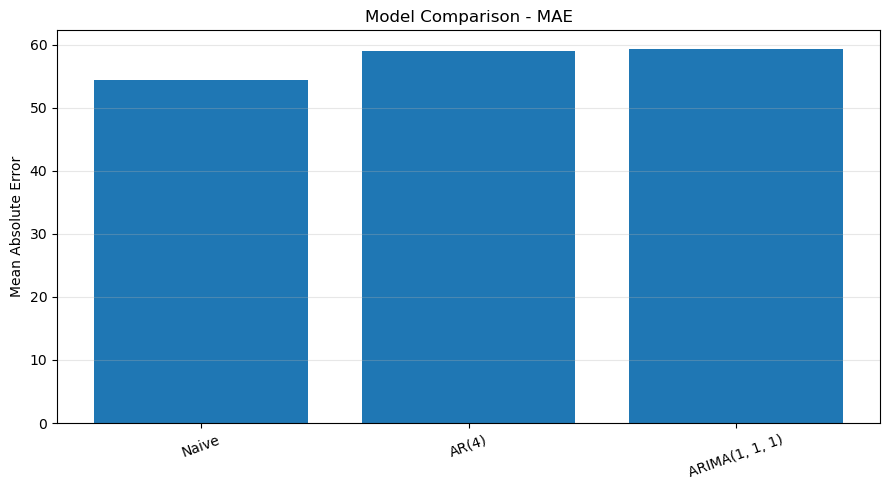

In [49]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(results_second["Model"], results_second["MAE"])
ax.set_title("Model Comparison - MAE")
ax.set_ylabel("Mean Absolute Error")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

### Model Performance Plot (RMSE) — Second (Replication) District

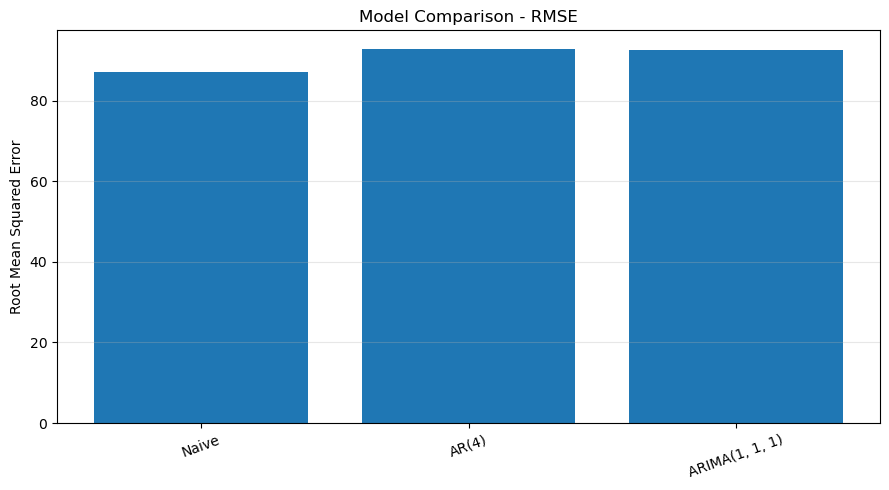

In [50]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(results_second["Model"], results_second["RMSE"])
ax.set_title("Model Comparison - RMSE")
ax.set_ylabel("Root Mean Squared Error")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

### Actual vs Forecasted Plot — Second (Replication) District

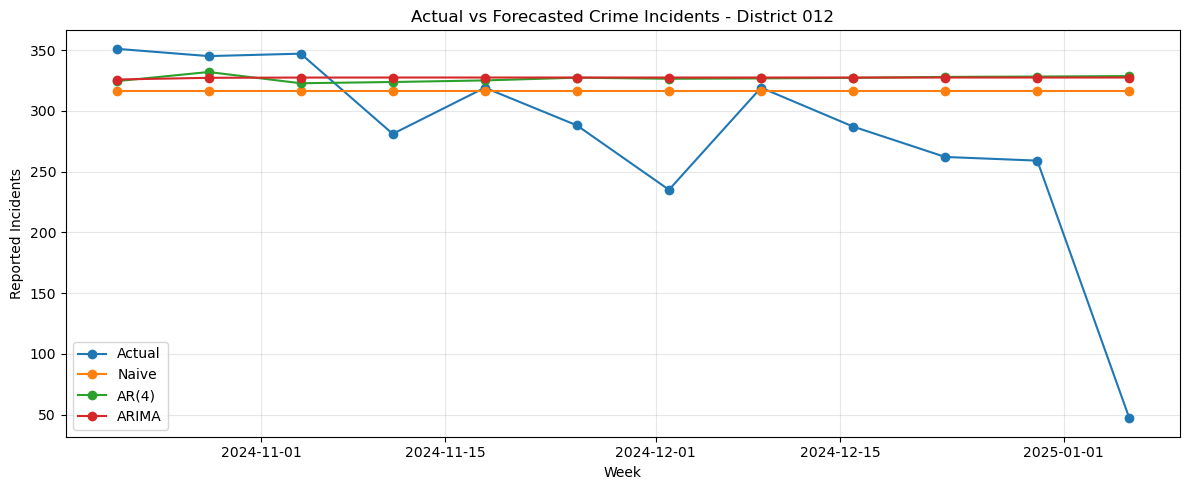

In [51]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_second.index, test_second.values, marker="o", label="Actual")
ax.plot(test_second.index, naive_pred_second, marker="o", label="Naive")
ax.plot(test_second.index, ar_pred_second, marker="o", label="AR(4)")
ax.plot(test_second.index, arima_pred_second, marker="o", label="ARIMA")
ax.set_title(f"Actual vs Forecasted Crime Incidents - District {second}")
ax.set_xlabel("Week")
ax.set_ylabel("Reported Incidents")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

### ARIMA Forecast with 95% Prediction Interval — Second (Replication) District

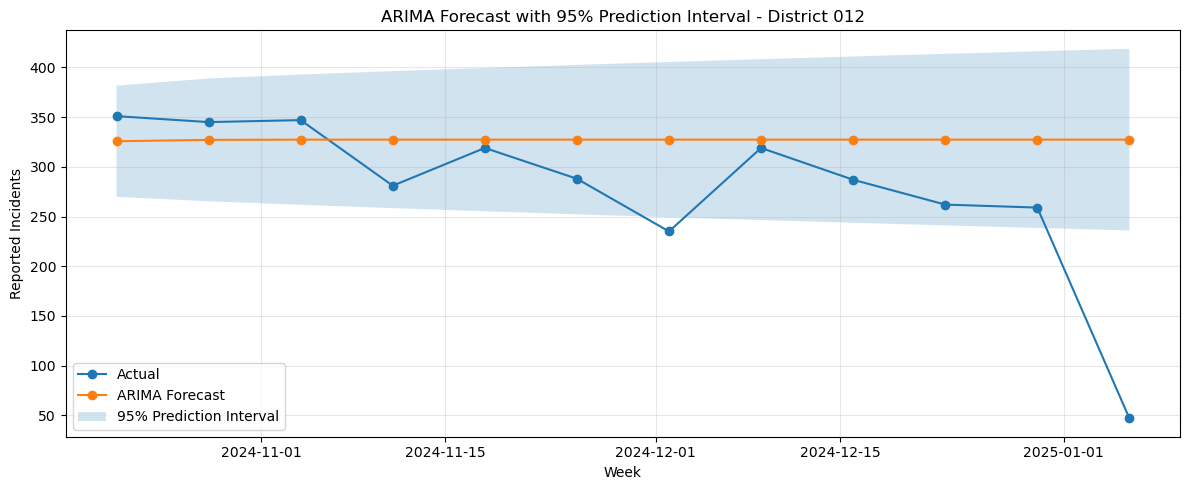

95% prediction interval coverage: 83.33%


In [52]:
forecast_result_second = arima_model_second.get_forecast(steps=len(test_second))
prediction_second = forecast_result_second.predicted_mean
ci_second = forecast_result_second.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_second.index, test_second.values, marker="o", label="Actual")
ax.plot(prediction_second.index, prediction_second.values, marker="o", label="ARIMA Forecast")
ax.fill_between(
    prediction_second.index, ci_second.iloc[:, 0].values, ci_second.iloc[:, 1].values,
    alpha=0.2, label="95% Prediction Interval",
)
ax.set_title(f"ARIMA Forecast with 95% Prediction Interval - District {second}")
ax.set_xlabel("Week")
ax.set_ylabel("Reported Incidents")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

coverage_second = float((
    (test_second.values >= ci_second.iloc[:, 0].values) &
    (test_second.values <= ci_second.iloc[:, 1].values)
).mean())
print(f"95% prediction interval coverage: {coverage_second:.2%}")

### Residuals Over Time — Second (Replication) District

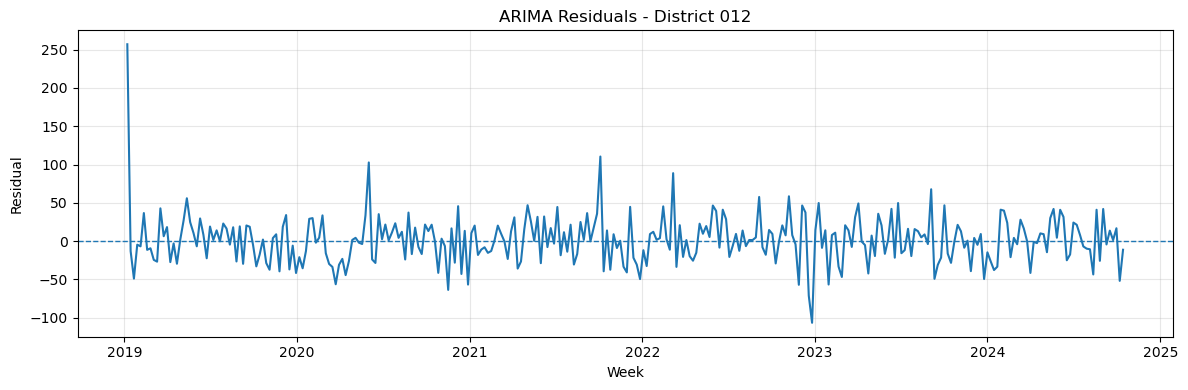

In [53]:
residuals_second = arima_model_second.resid.dropna()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(residuals_second.index, residuals_second.values)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title(f"ARIMA Residuals - District {second}")
ax.set_xlabel("Week")
ax.set_ylabel("Residual")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

### Residual Distribution — Second (Replication) District

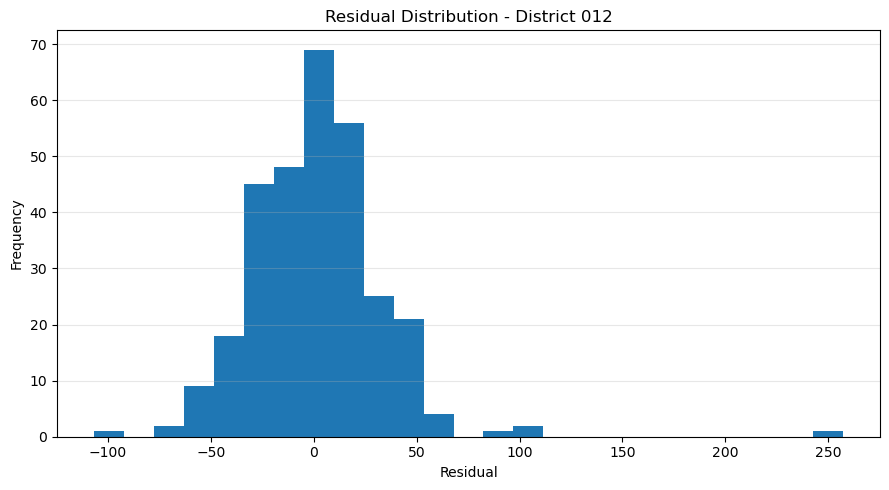

In [54]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(residuals_second, bins=25)
ax.set_title(f"Residual Distribution - District {second}")
ax.set_xlabel("Residual")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

### Residual Autocorrelation — Second (Replication) District

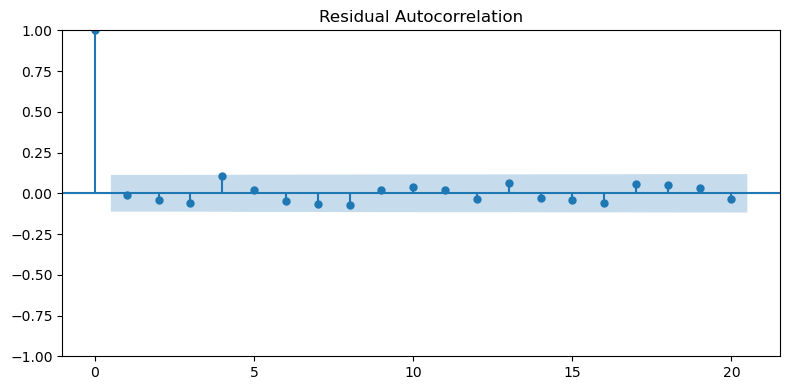

In [55]:
lag_value_resid_second = min(20, max(1, len(residuals_second) // 3))
fig, ax = plt.subplots(figsize=(8, 4))
plot_acf(residuals_second, lags=lag_value_resid_second, ax=ax)
ax.set_title("Residual Autocorrelation")
fig.tight_layout()
plt.show()

### Ljung-Box Test on Residuals — Second (Replication) District

In [56]:
lb_lag_second = min(10, max(2, len(residuals_second) // 10))
lb_second = acorr_ljungbox(residuals_second, lags=[lb_lag_second], return_df=True)
lb_p_second = float(lb_second["lb_pvalue"].iloc[0])

print(f"Ljung-Box test (lag={lb_lag_second}):")
print(lb_second)
print("Conclusion:", "Residuals show significant autocorrelation." if lb_p_second < 0.05 else "No strong evidence of remaining autocorrelation.")

Ljung-Box test (lag=10):
     lb_stat  lb_pvalue
10  8.950979   0.536762
Conclusion: No strong evidence of remaining autocorrelation.


### Rolling-Origin Backtest — Second (Replication) District

In [57]:
rolling_rows_second = []
initial_second = max(52, len(train_second) // 2)
end_second = initial_second
fold_second = 0

while end_second + CONFIG["rolling_horizon"] <= len(train_second):
    fold_second += 1
    fold_train_second = train_second.iloc[:end_second]
    fold_test_second = train_second.iloc[end_second:end_second + CONFIG["rolling_horizon"]]
    try:
        fold_model_second = ARIMA(fold_train_second, order=best_second["order"]).fit()
        fold_pred_second = fold_model_second.forecast(len(fold_test_second))
        rolling_rows_second.append({
            "fold": fold_second,
            "MAE": float(mean_absolute_error(fold_test_second, fold_pred_second)),
            "RMSE": float(mean_squared_error(fold_test_second, fold_pred_second) ** 0.5),
        })
    except Exception as exc:
        print(f"Fold {fold_second} failed: {exc}")
    end_second += CONFIG["rolling_step"]

rolling_df_second = pd.DataFrame(rolling_rows_second)

if len(rolling_df_second):
    print(rolling_df_second.to_string(index=False))
    print("Rolling validation summary:")
    print(rolling_df_second[["MAE", "RMSE"]].agg(["mean", "std"]))

 fold       MAE      RMSE
    1 43.808478 47.420172
    2 38.084991 49.591289
    3 19.627535 23.704313
    4 50.581700 56.331480
    5  6.458544  8.165456
    6 21.396268 27.252495
    7 37.979646 41.615016
    8 38.270642 50.514613
    9 26.077251 31.560470
   10 19.003172 23.217601
   11 23.441000 29.670774
   12 21.510160 30.133996
   13 17.012964 21.684561
   14 42.178478 49.611611
   15 32.098135 34.892794
   16 13.407481 16.681360
   17 49.919147 53.360127
   18 17.573369 21.596875
Rolling validation summary:
            MAE       RMSE
mean  28.801609  34.278056
std   13.108124  14.247484


### Auxiliary High/Low Crime Classification — Second (Replication) District

AUXILIARY HIGH/LOW CRIME CLASSIFICATION - District 012
Classification threshold (training median): 260.00
Confusion Matrix:
[[0 3]
 [0 9]]
Classification Report:
              precision    recall  f1-score   support

   Low Crime       0.00      0.00      0.00         3
  High Crime       0.75      1.00      0.86         9

    accuracy                           0.75        12
   macro avg       0.38      0.50      0.43        12
weighted avg       0.56      0.75      0.64        12



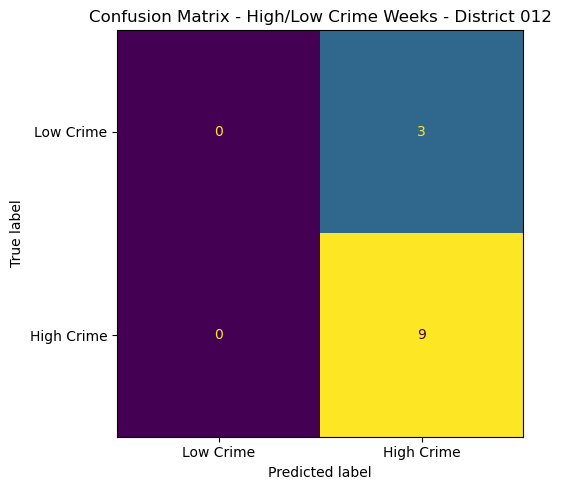

In [58]:
threshold_second = float(train_second.median())

actual_class_second = (np.asarray(test_second) >= threshold_second).astype(int)
predicted_class_second = (np.asarray(arima_pred_second) >= threshold_second).astype(int)

cm_second = confusion_matrix(actual_class_second, predicted_class_second, labels=[0, 1])
classification_report_second = classification_report(
    actual_class_second, predicted_class_second, labels=[0, 1],
    target_names=["Low Crime", "High Crime"], zero_division=0,
)

print(f"AUXILIARY HIGH/LOW CRIME CLASSIFICATION - District {second}")
print(f"Classification threshold (training median): {threshold_second:.2f}")
print("Confusion Matrix:")
print(cm_second)
print("Classification Report:")
print(classification_report_second)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_second, display_labels=["Low Crime", "High Crime"]).plot(
    ax=ax, values_format="d", colorbar=False,
)
ax.set_title(f"Confusion Matrix - High/Low Crime Weeks - District {second}")
fig.tight_layout()
plt.show()

### Save Outputs to Disk — Second (Replication) District

In [59]:
suffix_second = f"district{second}"

results_second.to_csv(OUT / f"model_comparison_{suffix_second}.csv", index=False)

pred_df_second = pd.DataFrame(
    {
        "actual": test_second.values,
        "naive": np.asarray(naive_pred_second),
        "AR": np.asarray(ar_pred_second),
        "ARIMA": np.asarray(arima_pred_second),
    },
    index=test_second.index,
)
pred_df_second.to_csv(OUT / f"test_predictions_{suffix_second}.csv")

if len(rolling_df_second):
    rolling_df_second.to_csv(OUT / f"rolling_origin_{suffix_second}.csv", index=False)

manifest_second = {
    "dataset": CONFIG["dataset_name"],
    "district": second,
    "start_date": CONFIG["start_date"],
    "end_date": CONFIG["end_date"],
    "frequency": CONFIG["frequency"],
    "n_total_periods": len(y_second),
    "n_train": len(train_second),
    "n_test": len(test_second),
    "ADF_statistic": float(adf_stat_second),
    "ADF_pvalue": float(adf_p_second),
    "selected_ARIMA_order": list(best_second["order"]),
    "selected_ARIMA_AIC": float(best_second["AIC"]),
    "Ljung_Box_pvalue": lb_p_second,
    "prediction_interval_coverage": coverage_second,
    "classification_threshold": threshold_second,
    "confusion_matrix": cm_second.tolist(),
    "python": sys.version,
    "platform": platform.platform(),
}

(OUT / f"manifest_{suffix_second}.json").write_text(
    json.dumps(manifest_second, indent=2, default=str), encoding="utf-8",
)

print(f"Outputs for district {second} saved.")

Outputs for district 012 saved.


## Cross-District Comparison Plot

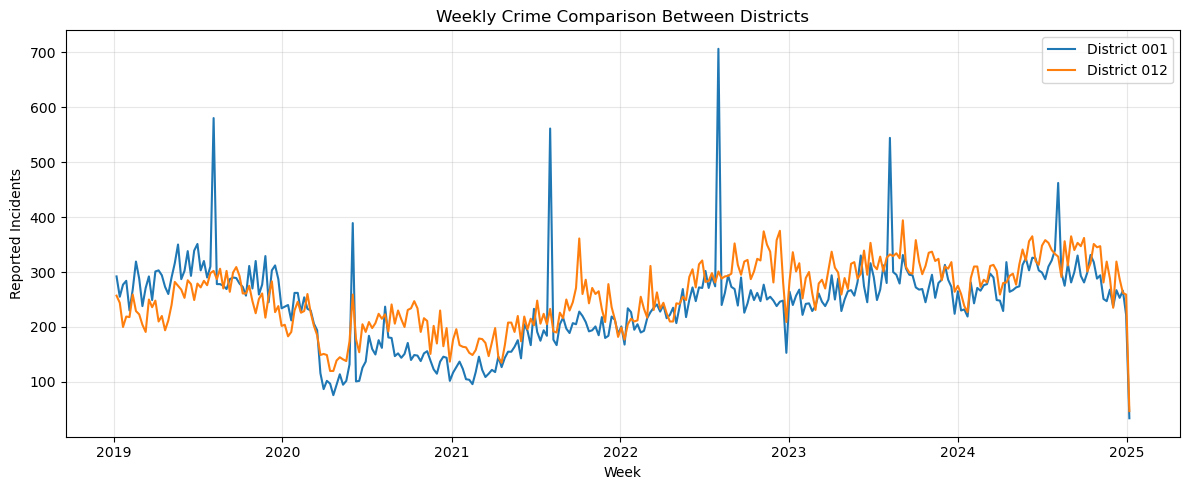

In [60]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y_primary.index, y_primary.values, label=f"District {primary}")
ax.plot(y_second.index, y_second.values, label=f"District {second}")
ax.set_title("Weekly Crime Comparison Between Districts")
ax.set_xlabel("Week")
ax.set_ylabel("Reported Incidents")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Cross-Location Model Comparison Table

In [61]:
combined = pd.concat(
    [results_primary.assign(District=primary), results_second.assign(District=second)],
    ignore_index=True,
)
print(combined.to_string(index=False))
combined.to_csv(OUT / "model_comparison_all_locations.csv", index=False)

         Model       MAE       RMSE District
         AR(4) 58.609849  87.627400      001
ARIMA(1, 1, 1) 64.499403  92.898178      001
         Naive 85.583333 109.598890      001
         Naive 54.500000  87.073724      012
         AR(4) 58.970326  92.772074      012
ARIMA(1, 1, 1) 59.344367  92.602800      012


## SARIMA Model Fit — Primary District

In [62]:
seasonal_period = 52
H = CONFIG["test_periods"]
sarima_train = y_primary.iloc[:-H]
sarima_test = y_primary.iloc[-H:]

if len(sarima_train) < 2 * seasonal_period:
    print("Not enough data for SARIMA.")
else:
    sarima_model = SARIMAX(
        sarima_train, order=(1, 1, 1), seasonal_order=(1, 0, 1, seasonal_period),
        enforce_stationarity=False, enforce_invertibility=False,
    ).fit(disp=False)

    sarima_pred = sarima_model.forecast(len(sarima_test))
    sarima_score = {
        "MAE": float(mean_absolute_error(sarima_test, sarima_pred)),
        "RMSE": float(mean_squared_error(sarima_test, sarima_pred) ** 0.5),
    }
    print("SARIMA:", sarima_score)

SARIMA: {'MAE': 63.206649189532044, 'RMSE': 87.08094314264174}


## SARIMA Forecast Plot — Primary District

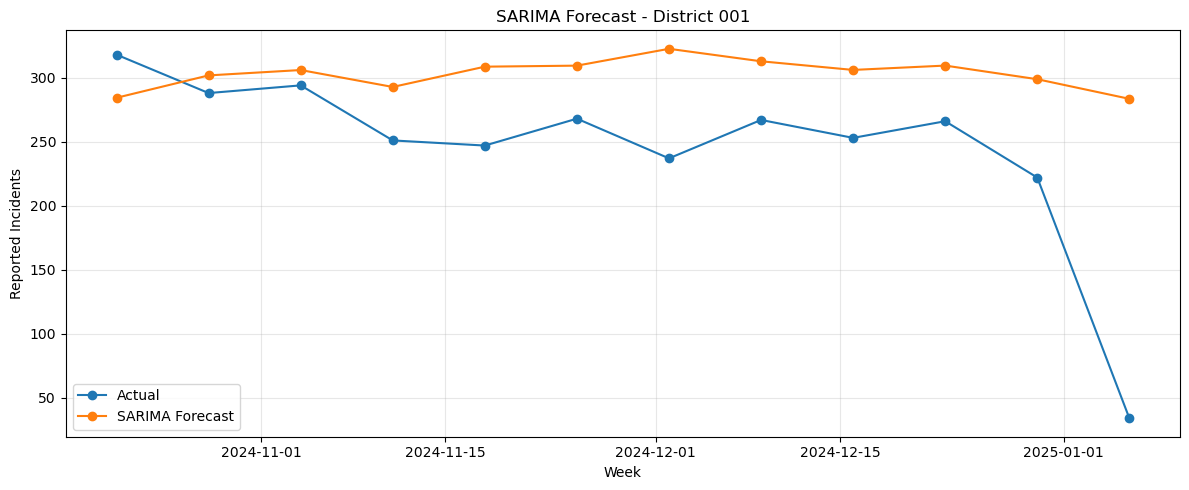

ANALYSIS COMPLETED SUCCESSFULLY
All outputs are stored in: C:\Users\Sarah Blessy\lab06_outputs
Note: Forecasts represent reported crime incident counts, not actual crime prevalence.


In [63]:
if len(sarima_train) >= 2 * seasonal_period:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(sarima_test.index, sarima_test.values, marker="o", label="Actual")
    ax.plot(sarima_test.index, sarima_pred, marker="o", label="SARIMA Forecast")
    ax.set_title(f"SARIMA Forecast - District {primary}")
    ax.set_xlabel("Week")
    ax.set_ylabel("Reported Incidents")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()

print("=" * 70)
print("ANALYSIS COMPLETED SUCCESSFULLY")
print("=" * 70)
print(f"All outputs are stored in: {OUT.resolve()}")
print("Note: Forecasts represent reported crime incident counts, not actual crime prevalence.")